In [1]:
!kaggle datasets download "shivamb/machine-predictive-maintenance-classification"

Dataset URL: https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification
License(s): CC0-1.0
  0%|                                                | 0.00/137k [00:00<?, ?B/s]
100%|█████████████████████████████████████████| 137k/137k [00:00<00:00, 175MB/s]


In [2]:
!unzip machine-predictive-maintenance-classification.zip -d machinepredictive

Archive:  machine-predictive-maintenance-classification.zip
  inflating: machinepredictive/predictive_maintenance.csv  


In [8]:
#predictive maintenance for manufacturing

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

#Load Data
df = pd.read_csv("machinepredictive/predictive_maintenance.csv")
print(df.head())
print(df.info())

#Preprocessing
df.drop(columns=["UDI", "Product ID"], inplace=True)

le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])

# Encode 'Failure Type' column (object type)
df["Failure Type"] = le.fit_transform(df["Failure Type"])

# Fix: ensure all columns are numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Fix: drop rows with NaN
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Features & Target
feature_cols = [c for c in df.columns if c not in ["Target", "Failure Type"]]
X = df[feature_cols].astype(float).values  # numpy array
y = df["Target"].astype(int).values        # numpy array

# Fix: replace any NaN/inf
X = np.nan_to_num(X)

#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\n--- Random Forest Results ---")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

# XGBoost ModeL
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("\n--- XGBoost Results ---")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]))


   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (tota

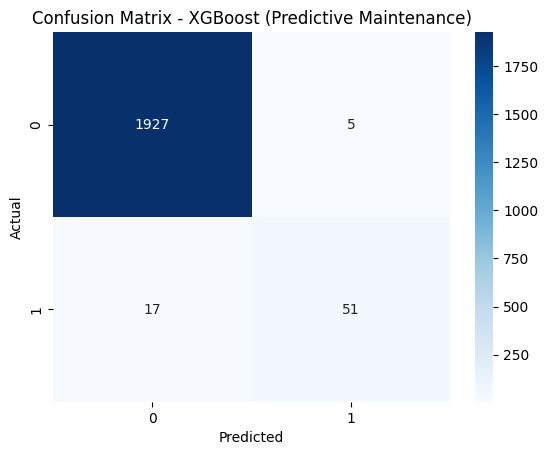

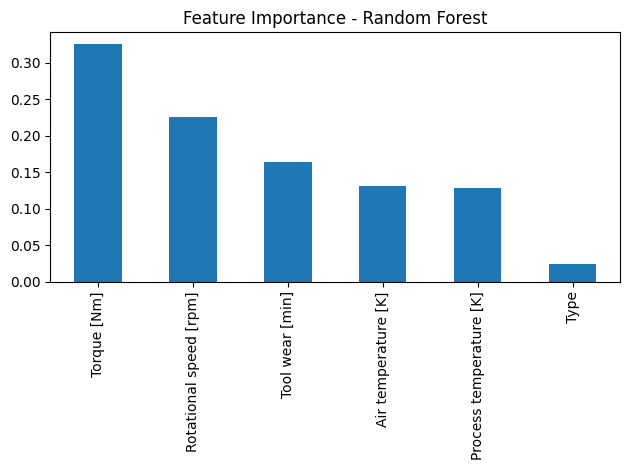

In [10]:
#Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost (Predictive Maintenance)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
feat_imp.plot(kind="bar", title="Feature Importance - Random Forest")
plt.tight_layout()
plt.show()